Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


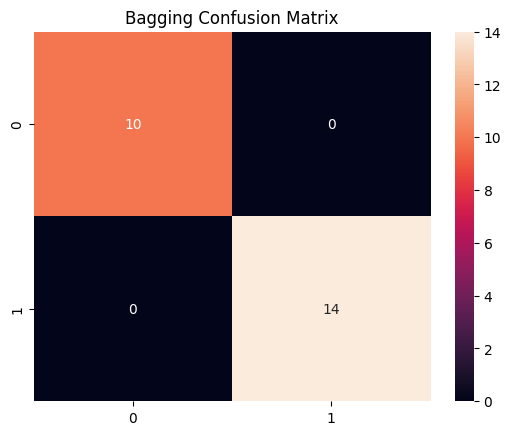

In [1]:
#24BAD006
#Ajay Krishnan T

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('diabetes_bagging.csv')

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

sns.heatmap(confusion_matrix(y_test, y_pred_bag), annot=True)
plt.title("Bagging Confusion Matrix")
plt.show()

In [4]:
#scenario 2

#24BAD006
#Ajay Krishnan T

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv('churn_boosting (1).csv')

df = pd.get_dummies(df)

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

ada = AdaBoostClassifier()
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))


AdaBoost Accuracy: 0.875
Gradient Boosting Accuracy: 0.875


Random Forest Accuracy: 1.0


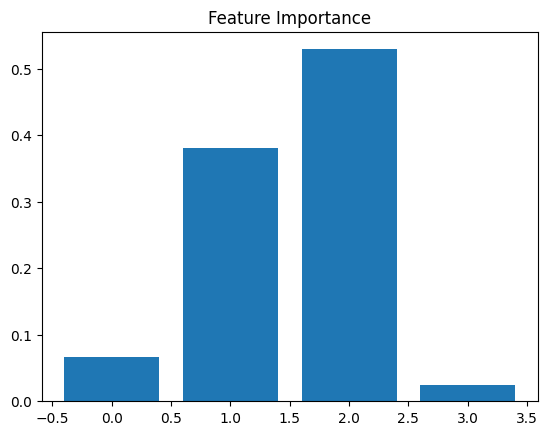

In [9]:
#24BAD006
#Ajay Krishnan T

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv('income_random_forest.csv')

df = pd.get_dummies(df)

X = df.drop('Income', axis=1)
y = df['Income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

rf = RandomForestClassifier(n_estimators=50)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))

importances = rf.feature_importances_
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance")
plt.show()

In [13]:

#24BAD006
#Ajay Krishnan T

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

df = pd.read_csv('heart_stacking.csv')

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

estimators = [
    ('lr', LogisticRegression(max_iter=1000)),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier())
]

stack = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
stack.fit(X_train, y_train)

y_pred = stack.predict(X_test)

print("Stacking Accuracy:", accuracy_score(y_test, y_pred))

Stacking Accuracy: 1.0


In [17]:
#24BAD006
#Ajay Krishnan T

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

df = pd.read_csv('fraud_smote.csv')

X = df.drop('Fraud', axis=1)
y = df['Fraud']

print("Before SMOTE:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

sm = SMOTE()
X_res, y_res = sm.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_res).value_counts())

model = DecisionTreeClassifier()
model.fit(X_res, y_res)

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

Before SMOTE:
 Fraud
0    110
1     10
Name: count, dtype: int64
After SMOTE:
 Fraud
0    90
1    90
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.25      0.25      0.25         4

    accuracy                           0.75        24
   macro avg       0.55      0.55      0.55        24
weighted avg       0.75      0.75      0.75        24

